In [33]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

from utils import preprocessing_remove_lines, preprocessing_split_by_characters, show_img, show_imgs

from tqdm import tqdm

In [2]:
def read_dir_images(dir_path):
    all_imgs = []
    for (root,dirs,files) in os.walk(dir_path,topdown=True):
        for file in tqdm(files, desc=f"Loading '{dir_path}' images"):
            if not file.endswith('.png'): # Remove non png
                continue
            if file.split("-")[1].split(".png")[0] != "0": # Remove bad datas
                continue
            
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)
            all_imgs.append((file.split("-")[0], preprocessing_remove_lines(img)))
    return all_imgs

In [133]:
test_imgs = read_dir_images('test')
print("total test imgs", len(test_imgs))

train_imgs = read_dir_images('clean_train_data')
print("total train imgs", len(train_imgs))

Loading 'test' images: 100%|██████████████| 2002/2002 [00:01<00:00, 1012.21it/s]


total test imgs 1935


Loading 'clean_train_data' images: 100%|██| 8001/8001 [00:07<00:00, 1068.45it/s]

total train imgs 7812


In [176]:
imgs_after_splits = []
wrong_captchas = ""
wrong_preprocess_count = 0
for (label, img) in tqdm(train_imgs):
    true_char_count = len(label)
    sep_type, char_imgs = preprocessing_split_by_characters(img)
    # Insert "_" between every characters
    new_label = "_".join(list(label))
    if len(char_imgs) != true_char_count:
        wrong_preprocess_count += 1
        # Show the img
        # show_img(img, title=label)
        # show_imgs(char_imgs)
        # input(f"Label: {label} - {char_count}/{true_char_count}, new label:")
        wrong_captchas += label + "\n"
    imgs_after_splits.append((new_label, char_imgs))
print(wrong_preprocess_count, "wrong preprocess count")
# print(wrong_captchas)

100%|███████████████████████████████████████| 7812/7812 [01:21<00:00, 96.26it/s]

309 wrong preprocess count


In [175]:
imgs_after_splits = []
wrong_captchas = ""
wrong_preprocess_count = 0
for (label, img) in tqdm(test_imgs):
    true_char_count = len(label)
    sep_type, char_imgs = preprocessing_split_by_characters(img)
    # Insert "_" between every characters
    new_label = "_".join(list(label))
    if len(char_imgs) != true_char_count:
        wrong_preprocess_count += 1
        # Show the img
        # show_img(img, title=label)
        # show_imgs(char_imgs)
        # input(f"Label: {label} - {char_count}/{true_char_count}, new label:")
        wrong_captchas += label + "\n"
    imgs_after_splits.append((new_label, char_imgs))
print(wrong_preprocess_count, "wrong preprocess count")

100%|███████████████████████████████████████| 1935/1935 [00:19<00:00, 97.20it/s]

68 wrong preprocess count


In [178]:
print(wrong_captchas)

mg1po
v8li
h2h3h09
e06k4rkg
rytxwi7c
sb8cjt
vpqb1za
n1r9hlf
99mqhb
mgimpd
hwq0huvj
88py
2hr9d9
lsxla
c0axp6o
orcbf
2ogcaj
226fxf
f7xtzu
scwj6qac
emggqtz
fvlsb
63xvslow
aqdlgv9
o7c24c2
7fnlfb4t
ihcir0z
df99hi2
qybzy5g
s1he2
fj57
rgcr6h4v
3tvbwkj
7ev3f8kb
iy5v
sltmu3i
ijv1
ifg6ly
jiznmz
rapb
k6oiqhlq
kyiyz
vueex1o4
2at5l1k9
y5h7lmio
q9hov1
sc3i
hvlr3f9y
422g0b
p4v8atio
qc61bz
s40m
mupzvuqx
m31nh
qdxgdkk
nz89zgfq
7heenhd
1yyo
pda2igde
115cip
e7ee3
ffy3glsp
xv0ozy3
v66jx27k
wsy867
ggnw0us
dkxo
1y2lk
qo7o
hihs
h977iqqc
bhcdr2wh
y0qo
fe7ous
ib0hh
8sq2w6z
ciyrfilw
u8ei
o6k3o5
kkdci6
it05
oqtd8il1
zj7qxhs
niq1q
m8lit3g3
9e83qa
pdvo1eu
59nl1yr5
96b7kz4p
inl0y9o
r29d2
dys8qz5r
7j3rw
ei8c8mhy
i4sg1hp
o43h15z8
db1htemj
71pk
wiv1fq
y47br5d3
cs50
ut6vavy
sjbse48d
gqy9e
xgedtm
7ih0
xqzv9s11
xsuiagc
2fgthyo9
zqzbvk
kjt9
etizrd
6ti6e1d
ky94up
y9ii18yh
ovanqq
wvl2i6
gjqy5
vauetjkk
9g69ig
zfcem
bi1a
rg1ce
3otukim
8ff3g25
ualfc
zeid7gsb
rkji6hbq
wcuvl
zt11k3v
jrrr
hbw1t2fs
mbi0yuwp
fhxcckp
0sz63i1
3qi9bll

In [174]:
import cv2
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
def am_power(a):
    dim1 = a.shape
    
    if len(dim1)==2:
        sz = dim1[0] * dim1[1] 
    elif len(dim1)==3:
        sz = dim1[0] * dim1[1] * dim1[2]        
    pa = np.sum( a ** 2.0) / sz    
    
    return pa
def preprocessing_split_by_characters(img: np.ndarray) -> tuple[int, list[np.ndarray]]:
    grey = np.mean(img, axis=2)
    grey_no_white = np.where(grey == 255, 0, 1)
    if am_power(grey_no_white) < 0.02:
        return 0, split_by_column(img)[1]
    else:
        return 1, segment_by_color(img)[1]

def split_by_column(img: np.ndarray) -> tuple[int, list[np.ndarray]]:
    grey_scale = img.mean(axis=2)
    grey_scale = cv2.GaussianBlur(grey_scale, (5,5), 0)
    
    col_values = np.where(grey_scale == 255, 0, 1)
    col_values = np.sum(col_values, axis=0)
    
    find_left = True
    unique_cols_range = []
    left = 0
    for i in range(len(col_values) - 1):
        if find_left and col_values[i] == 0 and col_values[i + 1] > 0:
            left = i
            find_left = False
        elif not find_left and col_values[i] > 0 and col_values[i + 1] == 0:
            right = i + 1
            unique_cols_range.append((left, right))
            find_left = True
    
    char_images = []
    for r in unique_cols_range:
        char_img = np.ones_like(img) * 255
        char_img[:, r[0]:r[1], :] = img[:, r[0]:r[1], :]
        char_images.append(char_img)

    return len(char_images), char_images
def segment_by_color(
    img: np.ndarray, 
    eps: float = 0.5,           # DBSCAN neighborhood radius (tuned)
    min_pixel_area: int = 50,   # Minimum pixel count per final blob
    db_min_samples: int = 27,   # Minimum pixels to form a cluster
    feature_weights: list[float] = [2, 0.01, 5, 5],  # Controls importance of each features, x_coord, y_coord, hue_x, hue_y
    visualise: bool = False
) -> tuple[int, list[np.ndarray]]:
    """
    Segments a CAPTCHA image using spatial + color (hue) clustering.

    - Converts image to HSV and filters out white background.
    - Maps hue to (cos, sin) to handle circular hue wraparound.
    - Clusters in 4D space: (x, y, cos(hue), sin(hue)) using DBSCAN.
    - Merges small gaps vertically to connect 'i' stems/dots.
    
    Args:
        img: Input RGB (or BGR) image as NumPy array.
        eps: DBSCAN neighborhood size (after scaling).
        min_pixel_area: Minimum size for a valid character blob.
        db_min_samples: Minimum samples for DBSCAN cluster.
        spatial_weight: Relative importance of spatial vs color distance.
    
    Returns:
        (character_count, list_of_character_images)
    """
    # --- 1. Convert to HSV ---
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s_channel = hsv[:, :, 1]
    v_channel = hsv[:, :, 2]

    # --- 2. Filter out white background ---
    s_thresh = 5
    v_thresh = 250
    bg_mask = cv2.bitwise_and(
        cv2.compare(s_channel, s_thresh, cv2.CMP_LT),
        cv2.compare(v_channel, v_thresh, cv2.CMP_GT)
    )
    fg_mask = cv2.bitwise_not(bg_mask)

    y_coords, x_coords = np.where(fg_mask > 0)
    if len(y_coords) < min_pixel_area:
        return 0, []

    # --- 3. Get hue values and map to circular coords ---
    hues = hsv[y_coords, x_coords, 0].astype(np.float32) / 180.0  # normalize hue to [0,1]
    hue_x = np.cos(2 * np.pi * hues)
    hue_y = np.sin(2 * np.pi * hues)

    # --- 4. Combine features: spatial + color ---
    features = np.column_stack([
        x_coords,
        y_coords, 
        hue_x,
        hue_y
    ])

    # --- 5. Normalize features (to make x,y comparable to hue) ---
    features_scaled = StandardScaler().fit_transform(features)
    features_scaled *= feature_weights  # re-apply spatial weight after scaling

    # --- 6. DBSCAN clustering ---
    db = DBSCAN(eps=eps, min_samples=db_min_samples).fit(features_scaled)
    labels = db.labels_
    unique_labels = set(labels)

    char_images = []
    char_bboxes = [[],[]]

    if visualise:
        show_img(img)
        # --- 9. Visualise clustering ---
        cluster_colors = {
            -1: 'black',  # noise
            0: 'red',
            1: 'green',
            2: 'blue',
            3: 'brown',
            4: 'yellow',
            5: 'purple',
            6: 'orange',
            7: 'pink',
            8: 'cyan',
            9: 'magenta'
        }
        
        # Convert hue_x and hue_y to a single hue value for coloring by hue
        # (inverse of how you generated hue_x, hue_y)
        hues = (np.arctan2(hue_y, hue_x) / (2 * np.pi)) % 1.0
        hsv_colors = plt.cm.hsv(hues)  # use HSV colormap for true hue visualization
        
        # Plot setup
        fig = plt.figure(figsize=(16, 7))
        
        # --- Left plot: colored by hue ---
        ax1 = fig.add_subplot(121, projection='3d')
        ax1.scatter(
            x_coords, y_coords, hue_x, 
            c=hsv_colors, s=5
        )
        ax1.set_xlabel('X coordinate')
        ax1.set_ylabel('Y coordinate')
        ax1.invert_yaxis()
        ax1.set_zlabel('Hue Value')
        ax1.set_title('Pixels Colored by Hue')
        
        # --- Right plot: colored by cluster label ---
        ax2 = fig.add_subplot(122, projection='3d')
        
        for label in unique_labels:
            mask = labels == label
            color = cluster_colors.get(label, 'gray')
            ax2.scatter(
                x_coords[mask], y_coords[mask], hue_x[mask],
                c=color, s=5, label=f'Cluster {label}' if label != -1 else 'Noise'
            )
        
        ax2.set_xlabel('X coordinate')
        ax2.set_ylabel('Y coordinate')
        ax2.invert_yaxis()
        ax2.set_zlabel('Hue Value')
        ax2.set_title(f'Pixels Colored by Cluster Label (Total: {len(unique_labels) - (1 if -1 in unique_labels else 0)} clusters)')
        ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
        
        plt.tight_layout()
        plt.show()
        
    # --- 7. Build masks for each cluster ---
    closed_masks = [] # For visualisation
    clustered_results = [] # For visualisation
    connected_components = [] # For visualisation
    for label in unique_labels:
        if label == -1:
            continue  # skip noise

        cluster_mask = np.zeros(img.shape[:2], dtype="uint8")
        cluster_idx = np.where(labels == label)[0]
        cluster_y = y_coords[cluster_idx]
        cluster_x = x_coords[cluster_idx]
        cluster_mask[cluster_y, cluster_x] = 255

        if visualise:
            i = np.full_like(img, 255, dtype=np.uint8)
            mask_bool = cluster_mask.astype(bool)
            i[mask_bool] = img[mask_bool]
            clustered_results.append(i)

        # --- 8. Morphological close (vertical kernel) ---
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
        closed_mask = cv2.morphologyEx(cluster_mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        closed_masks.append(closed_mask)

        # --- 9. Find connected components (characters) ---
        num_comp, comp_labels, stats, _ = cv2.connectedComponentsWithStats(closed_mask, 8, cv2.CV_32S)
        if num_comp <= 1:
            continue

        components = [] # For visualise
        small_area_imgs = []
        for i in range(1, num_comp):
            area = stats[i, cv2.CC_STAT_AREA]
            if visualise:
                final_mask = (comp_labels == i)
                y_pix, x_pix = np.where(final_mask)
                char_img = np.full_like(img, 255, dtype=np.uint8)
                char_img[final_mask] = img[final_mask]
                components.append(char_img)

            final_mask = (comp_labels == i)
            y_pix, x_pix = np.where(final_mask)
            if len(x_pix) == 0:
                continue

            x_min = x_pix.min()
            x_max = x_pix.max()

            # Create character image
            char_img = np.full_like(img, 255, dtype=np.uint8)
            char_img[final_mask] = img[final_mask]
            
            if area < min_pixel_area:
                small_area_imgs.append(char_img)
            else:
                char_images.append(char_img)
                char_bboxes[0].append(x_min)
                char_bboxes[1].append(x_max)
        connected_components.append(components)

    # --- 10. Sort characters left-to-right ---
    if char_bboxes:
        sorted_idx = np.argsort(char_bboxes[0])
        char_images = [char_images[i] for i in sorted_idx]
        char_bboxes[0] = [char_bboxes[0][i] for i in sorted_idx]
        char_bboxes[1]= [char_bboxes[1][i] for i in sorted_idx]


    if visualise:
        show_imgs(clustered_results, title="Cluster Results")
        for i, components in enumerate(connected_components):
            show_imgs([closed_masks[i], *components], title=f"Mask{i} with their connected components")
        show_imgs(char_images, title="Masked components and filter out small area components")
        
    # --- 11. Merge similar hue value and neighbour imgs
    hue_diff_thres = 0.5
    fin_images = []
    i = 0
    while(i < len(char_images)):
        if i == len(char_images) - 1:
            fin_images.append(char_images[i])
            break
        min_i, max_i = char_bboxes[0][i], char_bboxes[1][i]
        min_j, max_j = char_bboxes[0][i + 1], char_bboxes[1][i + 1]
        mean_i = (min_i + max_i) / 2
        mean_j = (min_j + max_j) / 2
        is_contain = (min_i < mean_j and max_i > mean_j) or (min_j < mean_i and max_j > mean_i)
        if is_contain and abs(mean_hue(char_images[i])- mean_hue(char_images[i+1])) < hue_diff_thres:
            fin_images.append(char_images[i] + char_images[i+1])
            i += 2
        else:
            fin_images.append(char_images[i])
            i += 1

    if visualise:
        show_imgs(fin_images, title="Merge neighbour components with similar hue value")
    return len(fin_images), fin_images

In [171]:
def mean_hue(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    grey = np.mean(img,axis=2)
    if np.sum(np.where(grey!=255, 1,0)) == 0: # No valid pixel
        return 100000
    return np.sum(np.where(grey!=255, hsv[:,:,0],0)) / np.sum(np.where(grey!=255, 1,0))

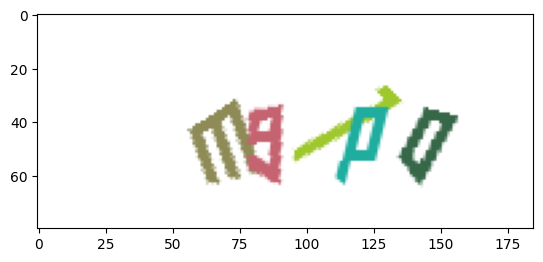

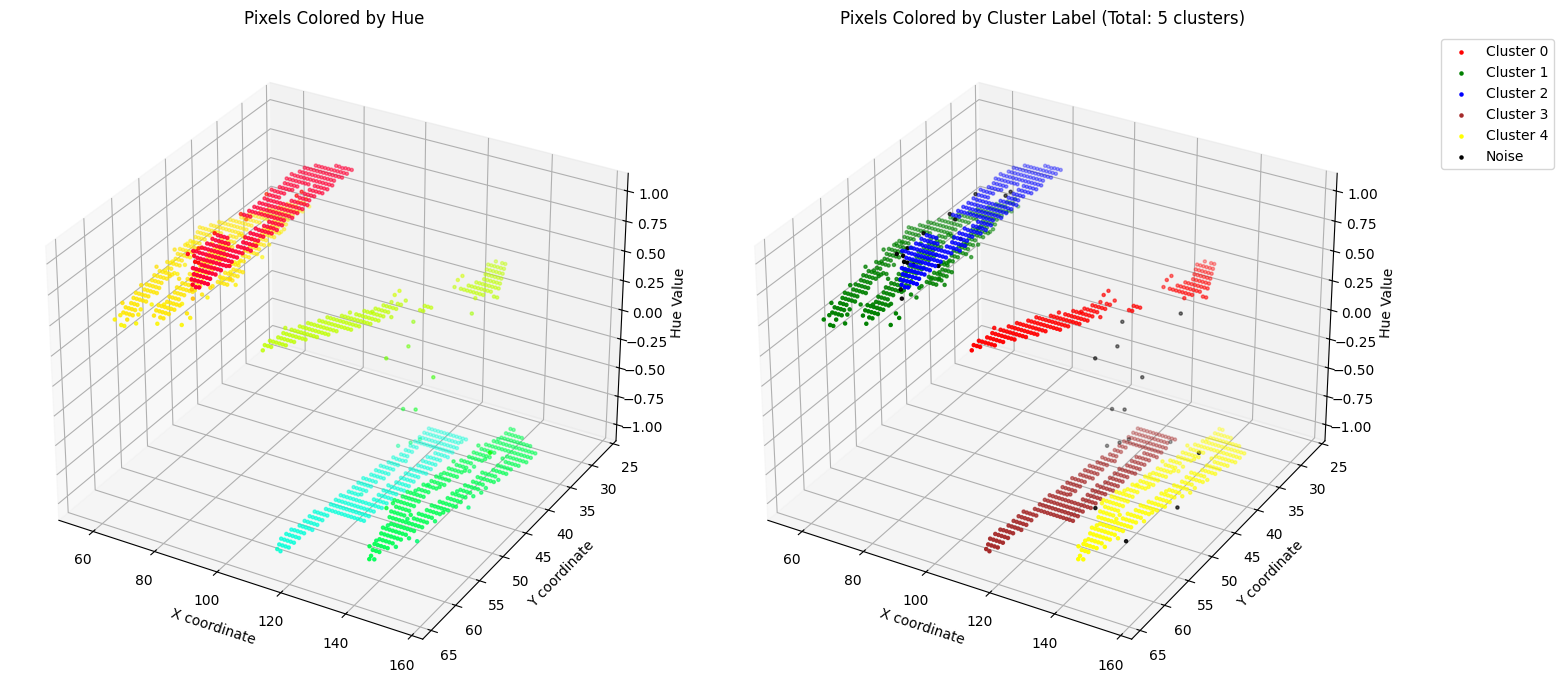

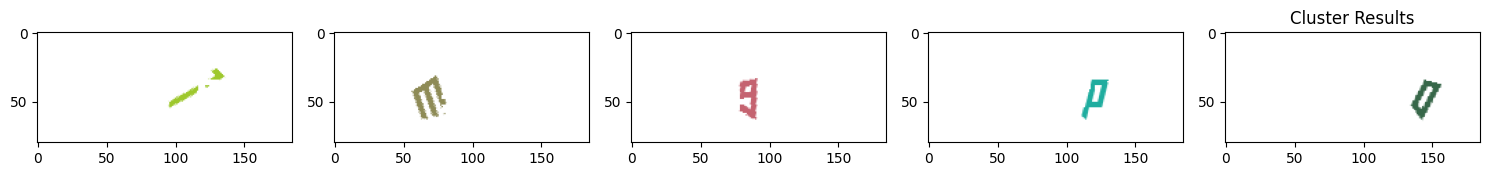

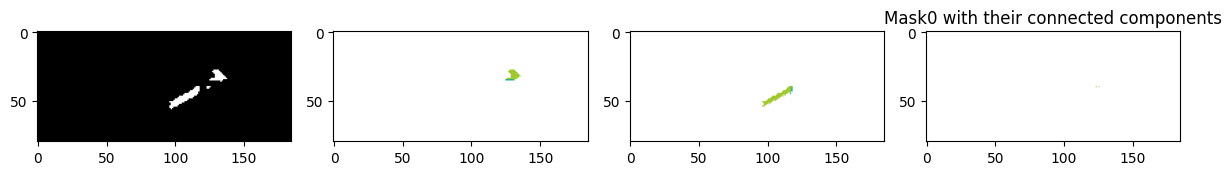

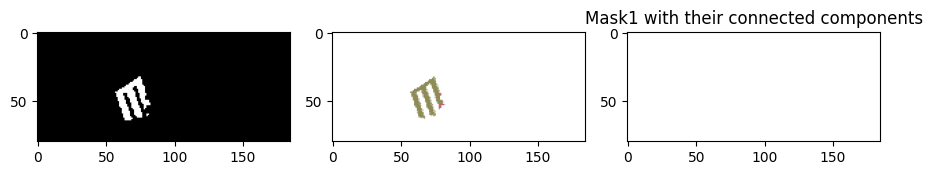

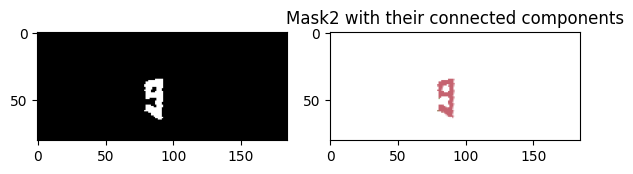

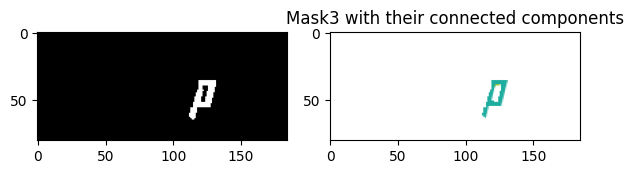

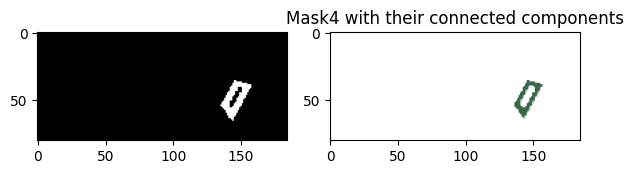

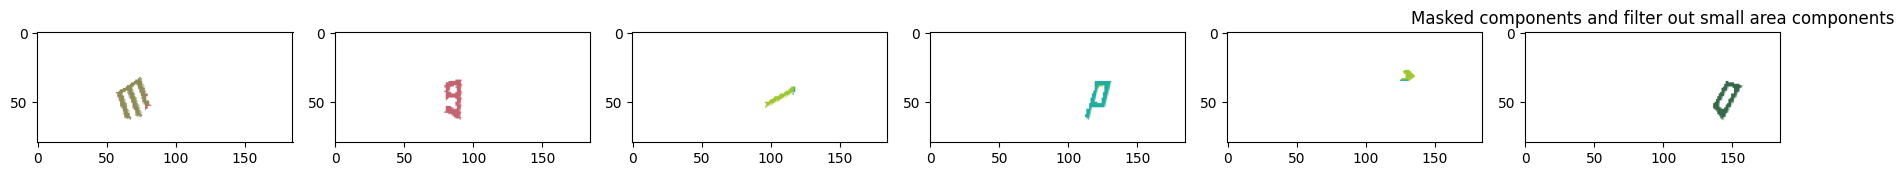

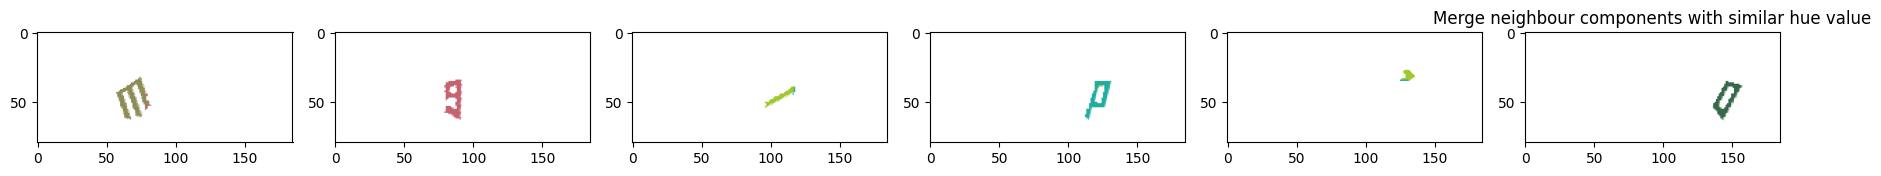

In [181]:
def find_label(label):
    for l, img in train_imgs:
        if label == l:
            return img
img = find_label("mg1po")
_, i = segment_by_color(img, visualise=True)

In [145]:
import string
print(list(string.ascii_lowercase))

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
